# Predicting HNLs from atmospheric D decays
This notebook does a quick estimate of HNL event rates in IceCube with D decays in the atmosphere as the source of HNLs. See the long email chain in response to the inital HNL paper for more context.

In general, the equation we're using is:

Number of HNLs produced:

$(\Phi_{\tau}(E, \cos{\theta}) +\Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X) ) \times U^2_{\tau 4} \times P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$

Number of HNLs detected:

N produced $\times (P_{\textrm{decay}} + P_{\textrm{interact}}) \times \textrm{efficiency}$


## Reviewing Carlos' initial estimate:



$N_{\textrm{HNL}} \approx (T A \Omega) ( \phi_{\nu_{\tau}} \times U^2) \times P_{\textrm{survival to detector}}\times P_{\textrm{decay in detector}}$


$N_{\nu_\mu} \approx (T A \Omega) ( \phi_{\nu_\mu}) \times P_{\textrm{int}}$


$N_{HNL} \approx (N_{\nu_\mu}) \times ( \phi_{\nu_\tau}/\phi_{\nu_\mu}) U^2 * (P_\textrm{decay in detector} \times P_\textrm{decay in detector}/P_{\textrm{int}})$

We have that, $N_{\nu_\mu} \approx 10^5$, for this analysis. In the deepcore energy range, optimistically, $\phi_{\nu_\tau}/\phi_{\nu_mu} \approx 10^{-5}$. 

We then consider two mass scales:
for $m \approx 0.1$ GeV, $c\tau\gamma \approx 10^2/U^2$ m, assuming an O(10 GeV) energy, so for an upgoing event selection search, 

$P_{\textrm{survival}} \approx \exp(-U^2\times10^4)$, while for $m \approx 1$ GeV, $c\tau\gamma \approx 10^{-2}/U^2$, so $P_{\textrm{survival}} \approx \exp(-U^2\times10^8)$; here we assume $L \approx$ O(1000km), since this is the smallest L-scale considered in our analysis. 

And $P_{\textrm{decay in detector}} = 1 - \exp(1\textrm{km}/c\tau\gamma)$, so 

$P_{\textrm{decay in detector}} = 1-\exp(-U^2\times 10)$ for 0.1 GeV and $1-\exp(-U^2 \times 10^3)$ for 1.0 GeV.
On the other hand, $P_{\textrm{int}} \approx 10^{-12}$ for this energy range. This means that
$N_{HNL_{0.1}} \approx (10^5) \times (10^{-5}) \times (\exp(-U^2\times10^4) \times (10^{12}) \times (U^2) = 10^{12} \times U^2 \times \exp(-U^2*10^4)$
for the 0.1 GeV, while for 1 GeV, we get
$N_{HNL_{1.0}} \approx 10^{12} * U^2 * \exp(-U^2*10^8)$


So for mixing $U^2 = 10^{-3}$, $N_{HNL_{1.0}}$ is 0, while $N_{HNL_{0.1}} \approx 451$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats
from scipy.integrate import quad
import scipy.integrate as integrate

import seaborn as sns
import matplotlib.cm as cm

import nuflux

In [2]:
import vegas
import math

In [3]:
#Global properties:
mHNL = 0.1 #GeV
U = 0.001 #mixing angle

## Tau neutrino flux: 

$\Phi_{\tau}(E, \cos{\theta}) + \Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X)$

In [4]:
def nutau_flux(E, cos_theta):
    '''
    Inputs:
    E, the D meson energy in GeV
    cos_theta, cosine of the zenith angle of the incoming D
    Output:
    differential flux for that energy and zenith angle
    
    We use nuflux (https://github.com/icecube/nuflux/blob/main/docs/overview.rst) 
    with H3a_SIBYLL23C_pr (https://arxiv.org/pdf/1806.04140)
    to get the prompt tau neutrino flux
    '''
    
    flux = nuflux.makeFlux('H3a_SIBYLL23C_pr')
    nu_type=nuflux.NuTau
    nu_energy=E # in GeV
    nu_cos_zenith = cos_theta
    flux_val = flux.getFlux(nu_type,nu_energy,nu_cos_zenith)
    
    return flux_val
    

In [5]:
def write_flux_dict(E_range, cos_theta_range):
    flux_dict = pd.DataFrame({"E":[], "cos_theta": [], "flux": []})
    counter = 0
    for E in E_range:
        for cos_theta in cos_theta_range:
            flux_dict.loc[counter]=([E, cos_theta, nutau_flux(E, cos_theta)])
            counter += 1
    return flux_dict

In [6]:
e_range = np.logspace(1, 10, 10)
ctheta_range = np.linspace(-1, 1, 15)

flux_dict = write_flux_dict(e_range, ctheta_range)

In [7]:
flux = flux_dict[flux_dict['E']==10][flux_dict['cos_theta']==1]['flux']
flux

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


14    8.023725e-11
Name: flux, dtype: float64

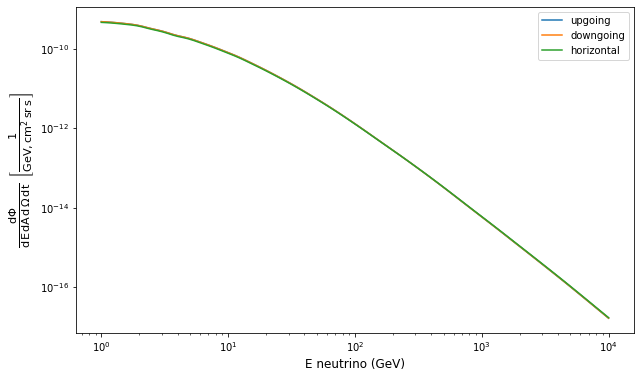

In [8]:
#Plot the flux
#According to nuflux documentation, the distributions should be the same for up- and downgoing particles
plt.figure(figsize=(10, 6))

e_points = np.logspace(0, 4, 100)
flux_up = nutau_flux(e_points, -1)
flux_down = nutau_flux(e_points, 1)
flux_side = nutau_flux(e_points, 0)

plt.plot(e_points, flux_up, label='upgoing')
plt.plot(e_points, flux_down, label='downgoing')
plt.plot(e_points, flux_side, label='horizontal')

plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel(r"$\frac{\rm{d}\Phi}{\rm{d}\,E\rm{d}A\,\rm{d}\,\Omega\,\rm{d}t}\ \left[\frac{1}{\rm{GeV},\rm{cm}^{2}\,\rm{sr}\,\rm{s}}\right]$",
          fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Zenith-integrated flux')

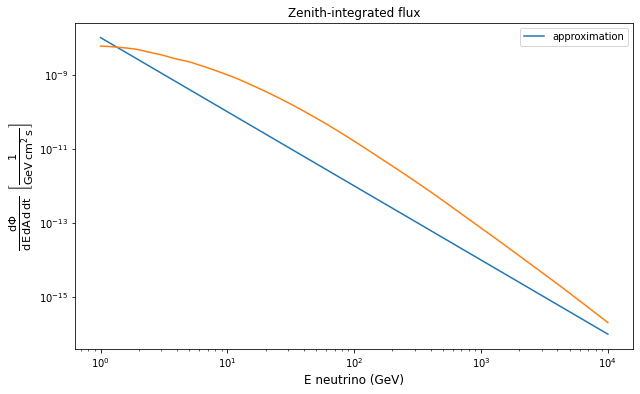

In [54]:
plt.figure(figsize=(10, 6))

e_points = np.logspace(0, 4, 100)
rough_e_dependence = (10**(-8))*(e_points**(-2))

def flux_wrapper(cos_zenith, energy):
    return 2*np.pi*nutau_flux(energy, cos_zenith)

integrated_flux = np.zeros(len(e_points))
for i, energy in enumerate(e_points):
    zenith_integrated_flux = quad(flux_wrapper, -1, 1, args=energy)[0]
#     print(zenith_integrated_flux)
    integrated_flux[i] = zenith_integrated_flux

plt.plot(e_points, rough_e_dependence ,label ="approximation")
plt.plot(e_points, integrated_flux)
plt.xlabel('E neutrino (GeV)',fontsize=12)
plt.ylabel(r"$\frac{\rm{d}\Phi}{\rm{d}\,E\rm{d}A\,\rm{d}\,\rm{d}t}\ \left[\frac{1}{\rm{GeV}\,\rm{cm}^{2}\,\rm{s}}\right]$",
          fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("Zenith-integrated flux")

In [10]:
# Now integrate the flux over energy and zenith:
seconds = 10**8 #total live time
total_nutau = np.array((integrate.nquad(nutau_flux, [[0,10000], [-1, 1]])))*2*np.pi*seconds
print(total_nutau)

[3.02496968 2.91314217]


In [11]:
# We're still missing the area integral
# It should represent the cross-sectional area of our detector. For now we use a rough order-of-magnitude:
# 1km^2 = 10^10cm^2
A = 10**10

## HNL Survival Probability:
$P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$

In [12]:
R = 6357 #polar radius of earth in km
IC_depth = 1.950 #depth from surface to center of IceCube in km

#Assuming earth is a circle centered at 0,0:

def surface_to_detector(cos_theta):
    '''
    Zenith is defined at the center of the detector, so we calculate distance from the center 
    of the detector, and then subtract 0.5km
    '''
    d = IC_depth

    neg_b = -2*(R-d)*cos_theta
    sqrt_b2_minus_4ac = np.sqrt(4*(R-d)**2*cos_theta**2 + 4*(2*R*d + d**2))
    two_a = 2
    
    distance = (neg_b + sqrt_b2_minus_4ac)/two_a # (neg_b - sqrt_b2_minus_4ac)/two_a is negative
    return distance - 0.5

In [13]:
def travel_distance (cos_zenith):
    '''
    From nuflux documentation:
    "The returned flux represents the flux incident on the surface of the earth, 
    no attempt is made to include oscillations or interaction losses while traveling through the Earth."
    
    However, we see a peak in HNL parent production at around 10-20km above earth's surface. 
    Therefore, assuming HNLs are produced as soon as the parent decays we need to take this distance traveled
    into account (probablisitcally), as well as the distance from the surface to the detector.
    
    According to (https://arxiv.org/pdf/1910.12839), parent fluxes are maximal at 15.4 km above the surface, 
    and drop off above energies of 10^10 GeV.
    At 10^10GeV, the mean decay distances (in the lab frame) are of the order cm or mm, and they scale with energy. 
    This is negligible compared to the height above earth's surface at which they are produced (and indeed, 
    are beyond the resolution of our detector), so we ignore this distance.
    
    We therefore approximate HNL travel distance as 15.4 + distance travelled through the earth.
    '''

    return 15.4 + surface_to_detector(cos_zenith)

def lifetime (mHNL, U2):
    '''
    Approximate HNL rest lifetime, as a function of its mass (GeV) and mixing with the tau neutrino.
    '''
    #U2 = U*U
    return 1*(10**(-6)/U2)*(0.1/mHNL)**5

def survival_probability (E, cos_zenith, mHNL=mHNL, U=0.001):
    '''
    The chance an HNL gets from production to the edge of the detector
    '''
    c_km = 3*10**5 #km
    c = 3*10**8
    
    travel_time = travel_distance(cos_zenith)/c_km #in the lab frame
    lorentz_gamma = E/mHNL #E/(mHNL*c)
    
    exponent = -travel_time/(lorentz_gamma*lifetime(mHNL, U))

    if (np.exp(exponent) > 0).any:
        return np.exp(exponent)
    return 1 + exponent
    
def cross_sectional_area():
    '''
    Gives the cross sectional area relevant to our flux and decay calculations
    Written as a function so we can input a more precise calculation in the future if desired
    '''
    area = 10**10 # 1 km^2 in units of cm^2
    return area

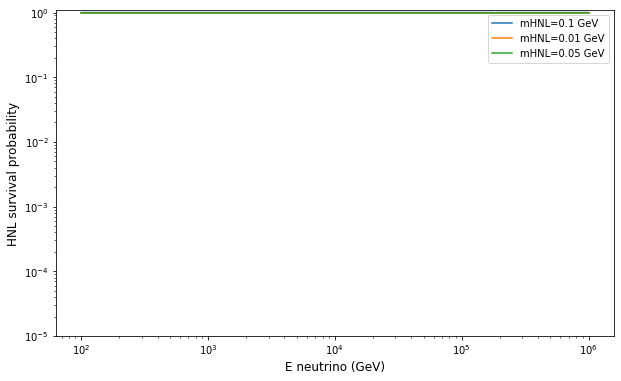

In [14]:
#Plot HNL survival probability as a function of energy, for a few masses and a mixing of U = 0.001

energies = np.logspace(2, 6, 100)
probs = survival_probability(energies, 1, mHNL=0.1)
probs_01 = survival_probability(energies, 1, mHNL=0.01)
probs_05 = survival_probability(energies, 1, mHNL=0.05)

plt.figure(figsize=(10, 6))
plt.plot(energies, probs, label = 'mHNL=0.1 GeV')
plt.plot(energies, probs_01, label = 'mHNL=0.01 GeV')
plt.plot(energies, probs_05, label = 'mHNL=0.05 GeV')


plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel('HNL survival probability',
          fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.ylim(10**(-5), 1.1)
plt.legend()

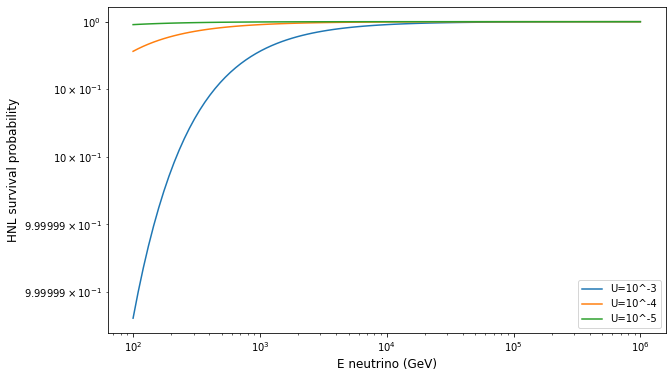

In [15]:
#Plot HNL survival probability as a function of energy, for a few mixings and a mass of m = 0.05

energies = np.logspace(2, 6, 100)
probs_3 = survival_probability(energies, 1, mHNL=0.05, U=0.001)
probs_4 = survival_probability(energies, 1, mHNL=0.05, U=0.0001)
probs_5 = survival_probability(energies, 1, mHNL=0.05, U=0.00001)

plt.figure(figsize=(10, 6))
plt.plot(energies, probs_3, label = 'U=10^-3')
plt.plot(energies, probs_4, label = 'U=10^-4')
plt.plot(energies, probs_5, label = 'U=10^-5')


plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel('HNL survival probability',
          fontsize=12)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(10**(-5), 1.1)
plt.legend()

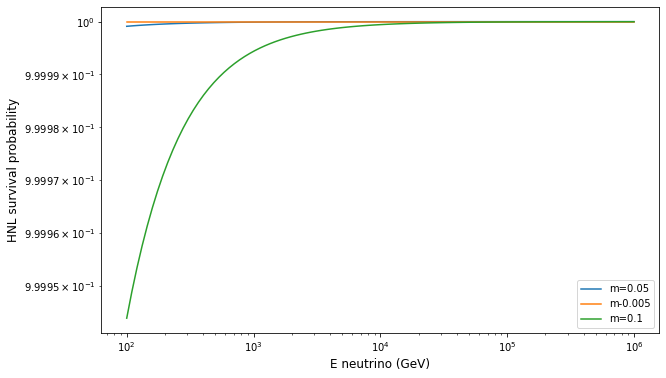

In [16]:
#Plot HNL survival probability as a function of energy, for a few mixings and a mass of m = 0.05

energies = np.logspace(2, 6, 100)
probs_3a = survival_probability(energies, 1, mHNL=0.05, U=0.001)
probs_4a = survival_probability(energies, 1, mHNL=0.005, U=0.001)
probs_5a = survival_probability(energies, 1, mHNL=0.1, U=0.001)

plt.figure(figsize=(10, 6))
plt.plot(energies, probs_3a, label = 'm=0.05')
plt.plot(energies, probs_4a, label = 'm-0.005')
plt.plot(energies, probs_5a, label = 'm=0.1')


plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel('HNL survival probability',
          fontsize=12)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(10**(-5), 1.1)
plt.legend()

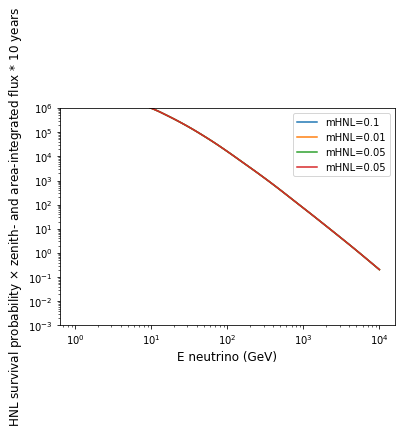

In [17]:
energies = np.logspace(0, 4, 100)
U = 0.001
probs_001 = survival_probability(energies, 1, mHNL=0.05)
plt.plot(energies, U*seconds*probs*integrated_flux*A, label = 'mHNL=0.1')
plt.plot(energies, U*seconds*probs_01*integrated_flux*A, label = 'mHNL=0.01')
plt.plot(energies, U*seconds*probs_05*integrated_flux*A, label = 'mHNL=0.05')
plt.plot(energies, U*seconds*probs_001*integrated_flux*A, label = 'mHNL=0.05')

plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel(r'HNL survival probability $\times$ zenith- and area-integrated flux * 10 years',
          fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.ylim(10**(-3), 10**6)
plt.legend()

## Number of HNLs reaching the detector:

$(\Phi_{\tau}(E, \cos{\theta}) +\Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X) ) \times U^2_{\tau 4} \times P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$


## Do the integral with vegas

In [17]:
import functools
m = 0.001
U = 0.00001

def total_events_predicted(m, U, integration_vars):
    '''
    Events predicted to reach the detector in 10 years
    '''
    seconds = 10*365*24*60*60 # seconds in ten years of live time
    cos_zenith, logE  = integration_vars
    E = 10**logE
    consts = 2*np.pi*seconds #Ie, not zenith dependent   
    A = cross_sectional_area()
    
    hnl_flux = U*nutau_flux(E, cos_zenith)
    
    survival_prob = survival_probability (E, cos_zenith, m, U)
    jacobian = E*np.log(10)
    
    return hnl_flux*survival_prob*consts*A*jacobian

part_func = functools.partial(total_events_predicted, m, U)


In [18]:
cos_z_range = [-1, 1]
E_range = [1, 6]

part_func = functools.partial(total_events_predicted, 0.01, 0.001)
integ = vegas.Integrator([cos_z_range, E_range])

result = integ(part_func, nitn=10, neval=10000)
print(result.summary())
print('result = %s    Q = %.2f' % (result, result.Q))

itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   4.2695(58)e+07  4.2695(58)e+07      0.00     1.00
  2   4.2767(31)e+07  4.2750(27)e+07      1.20     0.27
  3   4.2825(24)e+07  4.2793(18)e+07      2.69     0.07
  4   4.2758(19)e+07  4.2777(13)e+07      2.35     0.07
  5   4.2789(18)e+07  4.2781(11)e+07      1.84     0.12
  6   4.2791(15)e+07  4.27844(86)e+07     1.53     0.18
  7   4.2793(14)e+07  4.27868(73)e+07     1.32     0.24
  8   4.2807(13)e+07  4.27917(64)e+07     1.40     0.20
  9   4.2803(12)e+07  4.27940(57)e+07     1.31     0.23
 10   4.2810(12)e+07  4.27971(51)e+07     1.34     0.21

result = 4.27971(51)e+07    Q = 0.21


In [48]:
cos_z_range = [-1, 1]
E_range = [1, 6]
m_range = np.logspace(-6 ,-3,10)
U_range = np.logspace(-6, -3, 10)

integ = vegas.Integrator([cos_z_range, E_range])
events_predicted = pd.DataFrame({"m":[], "U":[], "num_incident":[]})
for i, mass in enumerate(m_range):
    print(i)
    for mixing in U_range:
        part_func = functools.partial(total_events_predicted, mass, mixing)      
        result = integ(part_func, nitn=10, neval=1000)
        events_predicted = pd.concat([pd.DataFrame([[mass, mixing, result.mean]], columns=events_predicted.columns), events_predicted], ignore_index=True)

0
1
2
3
4
5
6
7
8
9


In [49]:
events_predicted

,m,U,num_incident
0,0.001000,0.001000,4.283514e+07
1,0.001000,0.000464,1.988528e+07
2,0.001000,0.000215,9.224978e+06
3,0.001000,0.000100,4.278219e+06
4,0.001000,0.000046,1.984456e+06
...,...,...,...
95,0.000001,0.000022,9.219626e+05
96,0.000001,0.000010,4.280865e+05
97,0.000001,0.000005,1.985052e+05
98,0.000001,0.000002,9.226201e+04


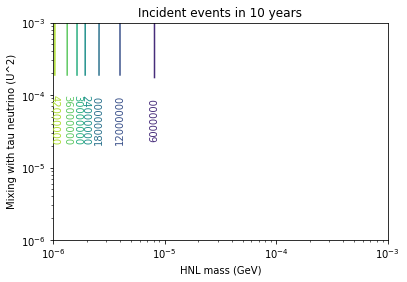

In [20]:
#Isoparticle contour for incident HNLs
X, Y = np.meshgrid(m_range, U_range)
n_events = np.array_split(events_predicted[:100]["num_incident"], len(m_range))

fig, ax = plt.subplots()
CS = ax.contour(X,Y,n_events)

ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Incident events in 10 years')
ax.set_xlabel("HNL mass (GeV)")
ax.set_ylabel("Mixing with tau neutrino (U^2)")
ax.set_xscale ("log")
ax.set_yscale("log")

## Interaction Probability:
$e^{-NC \times U^2_{\tau 4} \times cd}$

The neutral current cross section for tau neutrinos is (as far as I can tell, which isn't very far)about order 10^-39 cm^2. We must surpress this by a reasonable $U_{\tau 4}^2$ or order $10^{-3}$ at largest (more likely below $10^{-5}$. The maximum column depth a neutrino will pass through is (pulled from Alex Wen's slides from a few months back) 10^10 g/cm^2
Multplying the cross section, column depth, and mixing we get an exponent of order 10^-42 or smaller. (I'm not sure what to do with the gram unit, but even if we take the number of protons in a gram, the 10^26 factor won't make this statistically significant).

We don't have enough incoming neutrinos in the world for this to be relevant.

## Decay Probability:

In [18]:
def decay_probability (E, mHNL=mHNL, U=U):
    '''
    The chance an HNL decays at some point in the detector
    1 - chance HNL travels all the way through the detector
    '''
    c_km = 3*10**5 #km
    c = 3*10**8
    
    travel_time = 1/c_km #in the lab frame
    lorentz_gamma = E/mHNL # E/(mHNL*c)
    survival_prob = np.exp(-travel_time/(lorentz_gamma*lifetime(mHNL, U)))
    return 1-survival_prob

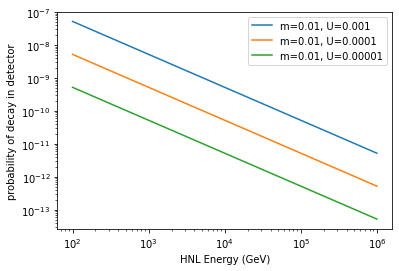

In [19]:
energies = np.logspace(2, 6, 100)

plt.plot(energies, decay_probability(energies, 0.05, 0.001), label='m=0.01, U=0.001')
plt.plot(energies, decay_probability(energies, 0.05, 0.0001), label='m=0.01, U=0.0001')
plt.plot(energies, decay_probability(energies, 0.05, 0.00001), label='m=0.01, U=0.00001')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('HNL Energy (GeV)')
plt.ylabel('probability of decay in detector')
plt.legend()
# plt.ylim(10**(-1), 2)

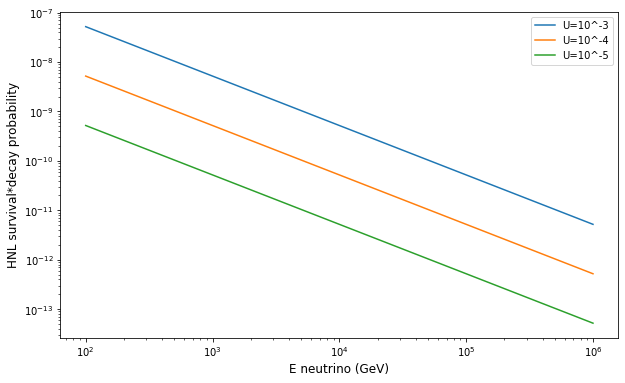

In [20]:
# Sanity check: Multiplying surival probability (ie, gets to the detector) by decay in detector probability

#Plot HNL survival probability as a function of energy, for a few mixings and a mass of m = 0.05

energies = np.logspace(2, 6, 100)
probs_3 = survival_probability(energies, 1, mHNL=0.05, U=0.001)*decay_probability(energies, mHNL=0.05, U=0.001)
probs_4 = survival_probability(energies, 1, mHNL=0.05, U=0.0001)*decay_probability(energies, mHNL=0.05, U=0.0001)
probs_5 = survival_probability(energies, 1, mHNL=0.05, U=0.00001)*decay_probability(energies, mHNL=0.05, U=0.00001)

plt.figure(figsize=(10, 6))
plt.plot(energies, probs_3, label = 'U=10^-3')
plt.plot(energies, probs_4, label = 'U=10^-4')
plt.plot(energies, probs_5, label = 'U=10^-5')


plt.xlabel('E neutrino (GeV)',
          fontsize=12)
plt.ylabel('HNL survival*decay probability',
          fontsize=12)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(10**(-5), 1.1)
plt.legend()

In [21]:
# Detector Efficiency: For now, we'll leave this at one and adjust later.
detector_efficiency=1

In [22]:
def total_events_detected(m, U, integration_vars):
    seconds = 10*365*24*60*60 # seconds in ten years of live time
    cos_zenith, logE  = integration_vars
    
    E = 10**logE
    jacobian = E*np.log(10) # np.log gives natural logarithm
    consts = 2*np.pi*seconds
    
    A = cross_sectional_area()
    hnl_flux = nutau_flux(E, cos_zenith)*U
    
    survival_prob = survival_probability (E, cos_zenith, m, U)
    decay_prob = decay_probability(E, m, U)
    
    return hnl_flux*survival_prob*consts*decay_prob*A*jacobian


In [23]:
cos_z_range = [-1, 1]
E_range = [1, 6]

part_func1 = functools.partial(total_events_detected, 0.01, 0.001)
# integ = vegas.Integrator([cos_z_range, E_range])

# result = integ(part_func1, nitn=10, neval=10000)
# print(result.summary())
# print('result = %s    Q = %.2f' % (result, result.Q))

NameError: name 'functools' is not defined

In [24]:
cos_z_range = [-1, 1]
E_range = [1, 6]
m_range = np.logspace(-6 ,-1,10)
U_range = np.logspace(-6, -3, 10)

integ = vegas.Integrator([cos_z_range, E_range])
events_detected = pd.DataFrame({"m":[], "U":[], "num_events":[]})
   
for i, mass in enumerate(m_range):
    print(i)
    for mixing in U_range:
        part_func = functools.partial(total_events_detected, mass, mixing)      
        result = integ(part_func, nitn=10, neval=1000)
        events_detected = pd.concat([pd.DataFrame([[mass, mixing, result.mean]], columns=events_detected.columns), events_detected], ignore_index=True)

0
1
2
3
4
5
6
7
8
9


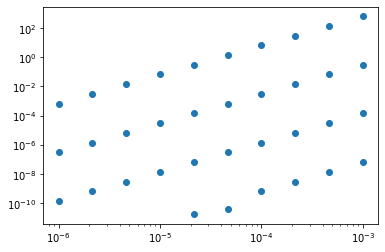

In [57]:
plt.scatter(events_detected['U'], events_detected['num_events'])
plt.xscale('log')
plt.yscale('log')

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: Log scale: values of z <= 0 have been masked
  if __name__ == '__main__':


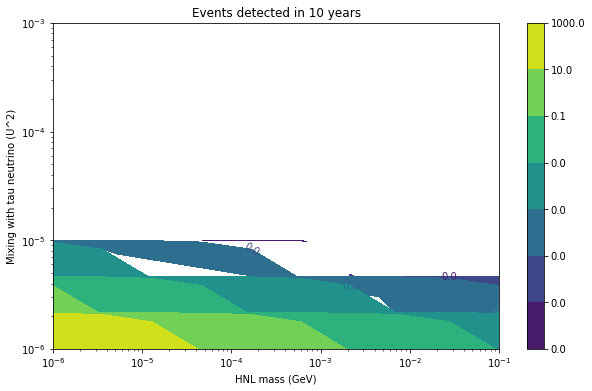

In [62]:
from numpy import ma
import matplotlib
#Isoparticle contour for detected HNLs
X, Y = np.meshgrid(m_range, U_range)
n_events = np.array_split(events_detected["num_events"], len(m_range))

fig, ax = plt.subplots(figsize=(10, 6))

CS = ax.contourf(X,Y,n_events, norm=matplotlib.colors.LogNorm())

# CS.yscale('log')
ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Events detected in 10 years')
ax.set_xlabel("HNL mass (GeV)")
ax.set_ylabel("Mixing with tau neutrino (U^2)")
ax.set_xscale ("log")
ax.set_yscale("log")
# ax.set_xlim(10**(-6), 10**(-5))
# ax.set_ylim(10**(-6), 10**(-5))
cbar = fig.colorbar(CS)

In [26]:
m_range = np.logspace(-6 ,-1,10)
U_range = np.logspace(-6, -3, 10)
# z = np.log(np.array(integration_results['num_detected']))
z = np.array(integration_results['num_detected'])
M, U = np.meshgrid(m_range, U_range)
Z = z.reshape((10, -1))

# plt.contourf(M, U, Z)
# # plt.legend()
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('mHNL')
# plt.ylabel('U^2')

# # Make a colorbar for the ContourSet returned by the contourf call.
# cbar = plt.colorbar()
# cbar.ax.set_ylabel('log(Events predicted in 10 years)')
# # cbar.ax.set_yscale('log')
# # Add the contour line levels to the colorbar
# # cbar.add_lines(CS2)
# plt.show()

NameError: name 'integration_results' is not defined

(1e-06, 1e-05)

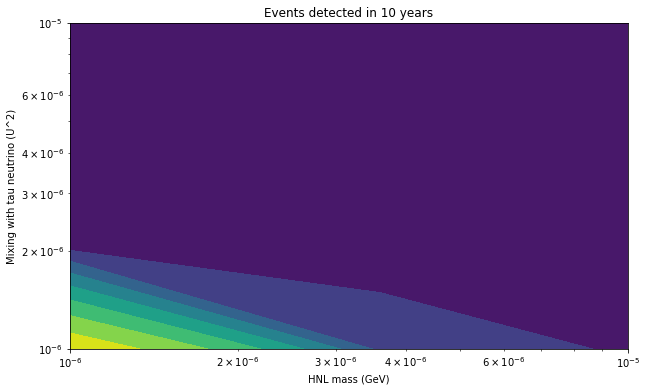

In [38]:
#Isoparticle contour for detected HNLs
X, Y = np.meshgrid(m_range, U_range)
n_events = np.array_split(events_detected["num_events"], len(m_range))

fig, ax = plt.subplots(figsize=(10, 6))
CS = ax.contourf(X,Y,n_events)
# CS.yscale('log')
# ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Events detected in 10 years')
ax.set_xlabel("HNL mass (GeV)")
ax.set_ylabel("Mixing with tau neutrino (U^2)")
ax.set_xscale ("log")
ax.set_yscale("log")
ax.set_xlim(10**(-6), 10**(-5))
ax.set_ylim(10**(-6), 10**(-5))

## Make plots from longer integral run

In [4]:
integration_results = pd.read_csv("predicted_events_compare_w_nick.csv") #pd.read_csv("predicted_events4.csv")
more_results = pd.read_csv("predicted_events4more.csv")
fullresults= pd.read_csv("predicted_events_newrange.csv")

In [5]:
len(fullresults)

10000

In [6]:
min(integration_results['m'])

0.001

In [29]:
noevents = fullresults["num_detected"]==0.0 #integration_results["num_detected"]==0.0
events = fullresults["num_detected"]!=0.0#integration_results["num_detected"]!=0.0
noevents.head

<bound method NDFrame.head of 0       False
1       False
2       False
3       False
4       False
        ...  
9995     True
9996     True
9997     True
9998     True
9999     True
Name: num_detected, Length: 10000, dtype: bool>

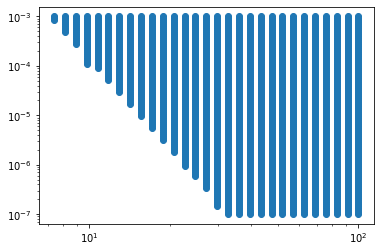

In [30]:
plt.scatter(fullresults[noevents]['m'], fullresults[noevents]['U'])
plt.xscale('log')
plt.yscale('log')

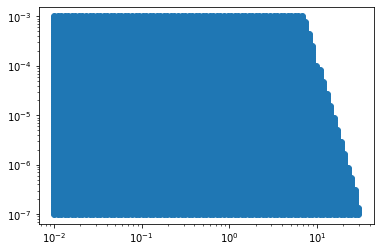

In [31]:
plt.scatter(fullresults[events]['m'], fullresults[events]['U'])
plt.xscale('log')
plt.yscale('log')

In [81]:
integration_results

,m,U,num_detected
0,0.000001,1.000000e-09,0.0
1,0.000001,1.149757e-09,0.0
2,0.000001,1.321941e-09,0.0
3,0.000001,1.519911e-09,0.0
4,0.000001,1.747528e-09,0.0
...,...,...,...
9995,10.000000,5.722368e-04,0.0
9996,10.000000,6.579332e-04,0.0
9997,10.000000,7.564633e-04,0.0
9998,10.000000,8.697490e-04,0.0


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import ma

from matplotlib import cm, ticker, colors

N = 100
# m_range = np.logspace(-6 ,1, N)
# U_range = np.logspace(-9, -3, N)

m_range = np.logspace(-3, 0, 100)
U_range = np.logspace(-4, -1, 100)

X, Y = np.meshgrid(m_range, U_range, indexing='ij')

z = np.asarray(integration_results["num_detected"])
z = z.reshape((100, -1))
# z = ma.masked_where(z <= 0, z)

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:12: UserWarning: Log scale: values of z <= 0 have been masked
  if sys.path[0] == '':


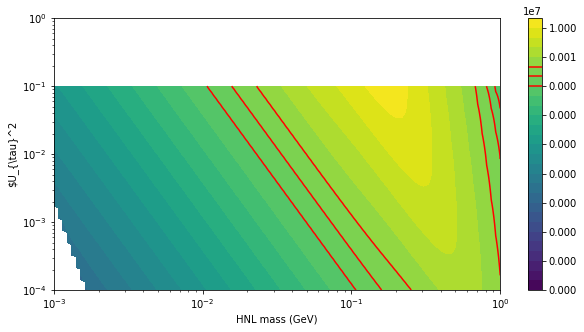

In [15]:
# Automatic selection of levels works; setting the
# log locator tells contourf to use a log scale:
plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()

# Alternatively, you can manually set the levels
# and the norm:
# lev_exp = np.arange(np.floor(np.log10(z.min())-1),
#                    np.ceil(np.log10(z.max())+1))
lev_exp = np.arange(-20., 9)
levs = np.power(10, lev_exp)
cs = ax.contourf(X, Y, z, levs, norm=colors.LogNorm())

cbar = fig.colorbar(cs)

CS2 = plt.contour(cs, levels=[10, 100, 1000], colors='r')
cbar.add_lines(CS2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
ax.set_xlim(0.001, 1)
ax.set_ylim(10**(-4), 1)
plt.show()

In [65]:
cs.levels[::2]

array([1.e-05, 1.e-03, 1.e-01, 1.e+01, 1.e+03, 1.e+05])

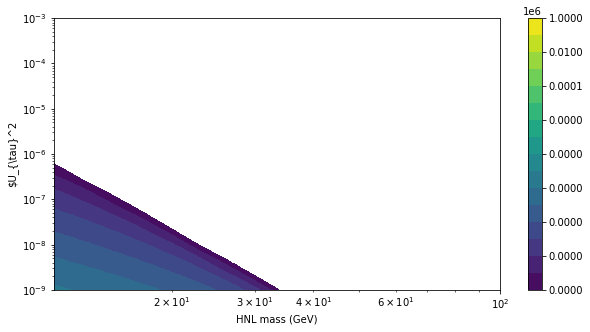

In [49]:
# #Add stuff from further integrals
N1 = 50
m_range1 = np.logspace(1.05, 2, 50)
U_range1 = np.logspace(-9, -3, 50)

X1, Y1 = np.meshgrid(m_range1, U_range1)

z1 = np.asarray(more_results["num_detected"])
z1 = z1.reshape((50, -1))

z1 = ma.masked_where(z1 <= 0, z1)

plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()

lev_exp = np.arange(-10., 7)
levs = np.power(10, lev_exp)
cs = ax.contourf(X1, Y1, z1, levs, norm=colors.LogNorm())

cbar = fig.colorbar(cs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
plt.show()

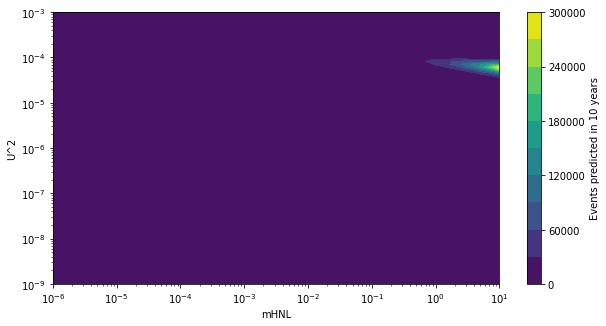

In [12]:
plt.rcParams['figure.figsize'] = [10, 5]

m_range = np.logspace(-6 ,1,100)
U_range = np.logspace(-9, -3, 100)

z = np.array(integration_results['num_detected'])
M, U = np.meshgrid(m_range, U_range)
Z = z.reshape((100, -1))

plt.contourf(M, U, Z, 10)
# plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('mHNL')
plt.ylabel('U^2')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = plt.colorbar()
cbar.ax.set_ylabel('Events predicted in 10 years')
# cbar.ax.set_yscale('log')
# Add the contour line levels to the colorbar

# CS2 = plt.contour(CS, levels=CS.levels[::2], colors='r')
# cbar.add_lines(CS2)
plt.show()

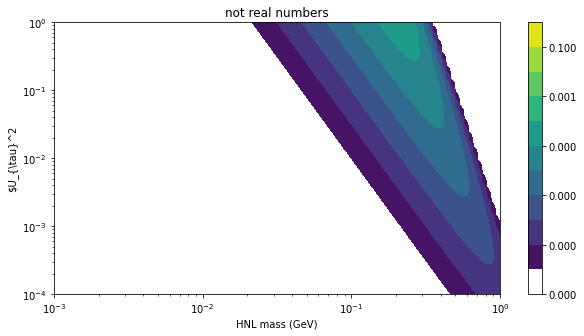

In [48]:
#Let's approximate ot find our expected U, m, dependence:

def approximate(m, U):
    A = 10000
    B = 1
    
    return U*np.exp(-A*U*m**6)*(1-np.exp(-B*U*m**6))

N = 100
m_range = np.logspace(-3 ,0., N)
U_range = np.logspace(-4, 0., N)
X, Y = np.meshgrid(m_range, U_range)

z = approximate(X, Y)


z = ma.masked_where(z <= 0, z)
plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()
# lev_exp = np.arange(np.floor(np.log10(z.min())-1),
#                    np.ceil(np.log10(z.max())+1))
lev_exp = np.arange(-323., 0.)
custom_levs=[-325, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0.]
levs = np.power(10, custom_levs)
cs = ax.contourf(X, Y, z, levs, norm=colors.LogNorm())
# cs1 = ax.contourf(X1, Y1, z1, levs, norm=colors.LogNorm())

cbar = fig.colorbar(cs)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
ax.set_title("not real numbers")
plt.show()

In [41]:
levs

array([0.e+000, 0.e+000, 1.e-323, 1.e-322, 1.e-321, 1.e-320, 1.e-319,
       1.e-318, 1.e-317, 1.e-316, 1.e-315, 1.e-314, 1.e-313, 1.e-312,
       1.e-311, 1.e-310, 1.e-309, 1.e-308, 1.e-307, 1.e-306, 1.e-305,
       1.e-304, 1.e-303, 1.e-302, 1.e-301, 1.e-300, 1.e-299, 1.e-298,
       1.e-297, 1.e-296, 1.e-295, 1.e-294, 1.e-293, 1.e-292, 1.e-291,
       1.e-290, 1.e-289, 1.e-288, 1.e-287, 1.e-286, 1.e-285, 1.e-284,
       1.e-283, 1.e-282, 1.e-281, 1.e-280, 1.e-279, 1.e-278, 1.e-277,
       1.e-276, 1.e-275, 1.e-274, 1.e-273, 1.e-272, 1.e-271, 1.e-270,
       1.e-269, 1.e-268, 1.e-267, 1.e-266, 1.e-265, 1.e-264, 1.e-263,
       1.e-262, 1.e-261, 1.e-260, 1.e-259, 1.e-258, 1.e-257, 1.e-256,
       1.e-255, 1.e-254, 1.e-253, 1.e-252, 1.e-251, 1.e-250, 1.e-249,
       1.e-248, 1.e-247, 1.e-246, 1.e-245, 1.e-244, 1.e-243, 1.e-242,
       1.e-241, 1.e-240, 1.e-239, 1.e-238, 1.e-237, 1.e-236, 1.e-235,
       1.e-234, 1.e-233, 1.e-232, 1.e-231, 1.e-230, 1.e-229, 1.e-228,
       1.e-227, 1.e-

## Old Integration Functions

In [35]:
def diff_hnls_produced(E, cos_zenith, mHNL=mHNL, U=U):
    '''
    differential rate of HNL production at the detector surface, in Hz
    '''
    return nutau_flux(E, cos_zenith)*U*survival_probability(E, cos_zenith, mHNL=mHNL, U=U)

In [36]:
seconds = 10*365*24*60*60 # seconds in ten years of live time
diff_hnls_produced(4000, 0.5)*seconds

4.3857815957092e-215

In [37]:
def zenith_integral_wrapper(cos_zenith, E, mhnl, U):
    return 2*np.pi*diff_hnls_produced(E, cos_zenith, mhnl, U)*seconds

# Integrate my_function from 0 to 1
result, error = quad(zenith_integral_wrapper, -1, 1, args=(100, 0.1, U))

print("Result:", result)
print("Error:", error)

# Perhaps counterintuitively, thus far we do better with a smaller mixing, because the particle needs to 
# NOT interact until it reaches the detector. 

Result: 0.0
Error: 0.0


In [134]:
result, error = integrate.nquad(zenith_integral_wrapper, [[-1, 1], [10, 100000]], args=(0.01, U))
print(U)
print("Over ten years, this would give: ", result)

1e-05
Over ten years, this would give:  3.7752905846746856e-05


In [39]:
def allover_zenith_wrapper(cos_zenith, E, m, U):
    consts = 2*np.pi*seconds*U #Ie, not zenith dependent
    
    
    c_km = 3*10**5
    c = 3*10**8
    travel_time = travel_distance(cos_zenith)/c_km #in the lab frame
    lorentz_gamma = E/(mHNL*c)
    
    exponent = -travel_time/(lorentz_gamma*lifetime(mHNL, U))
    survival_prob = np.exp(exponent)
    survival_prob_approx = 1 + exponent

    return nutau_flux(E, cos_zenith)*survival_prob*consts
    

In [40]:
def E_wrapper (E, m, U):
    return quad(allover_zenith_wrapper, -1, 1, args=(E, m, U))[0]

def total_integral (minE, maxE, m, U):
    return quad(E_wrapper, minE, maxE, args = (m, U))

In [41]:
minE = 100
maxE = 10**6

mHNL = 0.01
U2 = 0.001
tots = total_integral(minE, maxE, mHNL, U2)[0]

print(tots)

0.00023173970522664538
